In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

# First, write a code where, by changing just the keyword, we can search for multiple things.

### Setup pytrends library and keyword define

In [2]:
pytrends = TrendReq(hl = 'en-US', tz=360)
keyword = 'cloud computing'

# Data Request

In [3]:
pytrends.build_payload([keyword], cat=0, timeframe='today 12-m', geo='', gprop='')

# Top 15 countries where the keywords are searched the most, and also create visual representation it.

### Country Wise Interest

In [4]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by = keyword,ascending=False).head(15)

C:\Users\HP\AppData\Local\Temp\ipykernel_14104\360136734.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_data[keyword], y=region_data.index, palette="Blues_d")


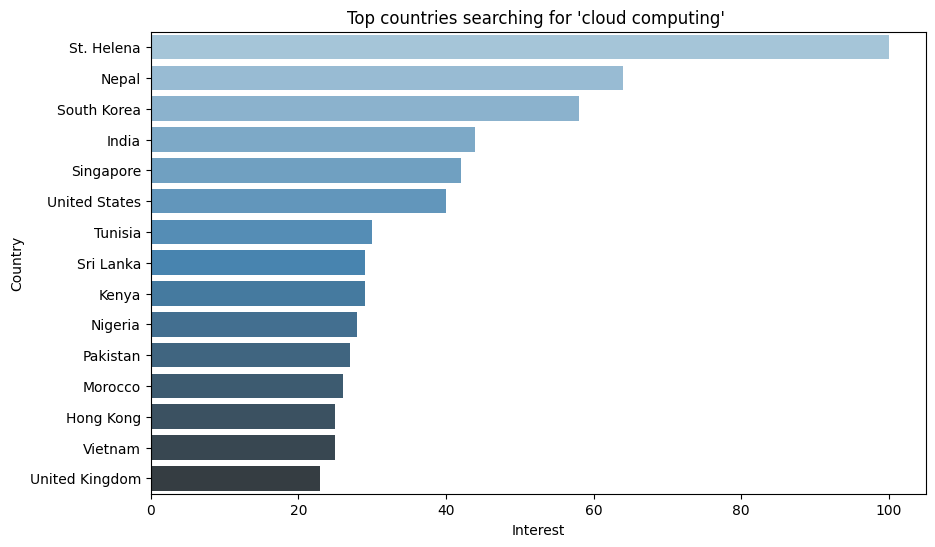

In [5]:
plt.figure(figsize=(10,6))
sns.barplot(x=region_data[keyword], y=region_data.index, palette="Blues_d")
plt.title(f"Top countries searching for '{keyword}' ")
plt.xlabel("Interest")
plt.ylabel("Country")

plt.show()

# A world map needs to be plotted showing the countries that search the keyword the most.

## World Map

In [6]:
region_data = region_data.reset_index()

fig = px.choropleth(region_data,
                    locations='geoName',
                    locationmode='country names',
                    color=keyword,
                    title=f"search interest for '{keyword}' by country",
                    color_continuous_scale='Blues')

fig.show()

# We need to extract the time-wise interest of the keyword - how it tended in different years. 

## Time-Wise Interest

In [7]:
time_df = pytrends.interest_over_time()

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



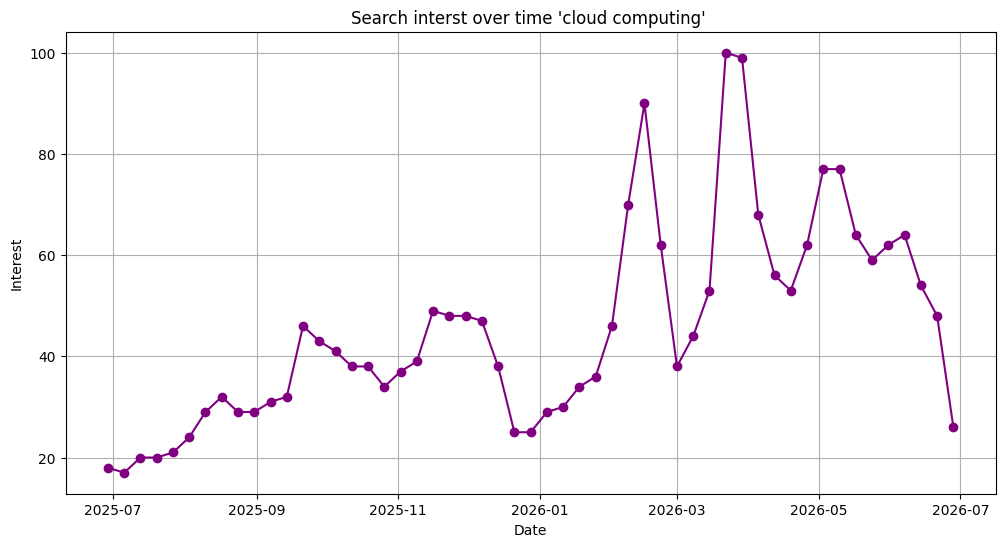

In [8]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index, time_df[keyword], marker='o', color='purple')
plt.title(f"Search interst over time '{keyword}' ")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)

plt.show()

# Compare related keywords and plot the graph

## Multiple keywords compare

In [9]:
kw_list = ['cloud computing', 'data science', 'machine learning']   # different keywords

pytrends.build_payload(kw_list, cat=0, timeframe='today 12-m', geo='', gprop='')

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



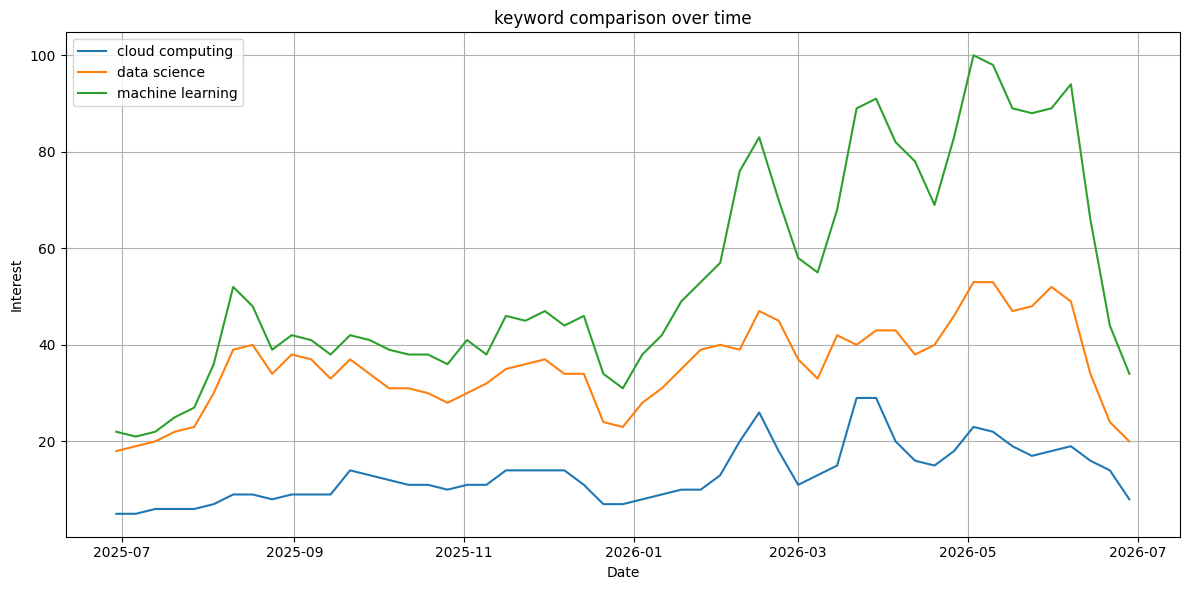

In [10]:
compare_df = pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label=kw)

plt.title("keyword comparison over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()